# NB04: Enriched NB Model with CV Score (RQ4)

**RQ4:** Does adding the CV-predicted safety score improve model fit?

Load the baseline model from NB03 and add `cv_score_predicted` as a single
additional predictor. Test improvement using a nested LR test.

**Reads:** `data/processed/nb_model_ready.csv`, `data/processed/model_baseline.pkl`, `data/processed/baseline_results.json`
**Writes:** `outputs/model_enriched.pkl`, `outputs/nb_model_results.json`, `outputs/nb_comparison_table.csv`

> **NOTE:** CV scores used here are PRELIMINARY — CV model trained on N=63
> pilot-survey intersections (Spearman rho=0.391, MAE=0.189).
> Re-estimate once full survey labels are available.

## Inputs / Outputs

| Direction | File | Description |
|-----------|------|-------------|
| Input | `data/processed/nb_model_ready.csv` | Clean joined dataset from NB01 |
| Input | `data/processed/model_baseline.pkl` | Fitted baseline NB model from NB03 |
| Input | `data/processed/baseline_results.json` | Selected vars and coefficients from NB03 |
| Output | `outputs/model_enriched.pkl` | Fitted enriched NB model object |
| Output | `outputs/nb_model_results.json` | Full results: both models, LR test, AIC comparison |
| Output | `outputs/nb_comparison_table.csv` | Side-by-side coefficient table (thesis-ready) |

In [ ]:
import json
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import NegativeBinomial, Poisson

warnings.filterwarnings("ignore")

# ROOT is one level up from pipeline/ — mirrors the pattern in NB01–NB03
ROOT      = Path("..").resolve()
OUTPUTS   = ROOT / "outputs"               # final deliverables (model_enriched.pkl, results JSON, etc.)
PROCESSED = ROOT / "data" / "processed"   # intermediate files: prepared dataset + baseline model from NB03
PLOTS     = OUTPUTS / "diagnostic_plots"
PLOTS.mkdir(parents=True, exist_ok=True)

# Load prepared dataset — never raw data
df = pd.read_csv(PROCESSED / "nb_model_ready.csv", dtype={"intersection_id": int})

# Load baseline model from NB03 (for reference; we refit on df_p4 for a valid LR test)
with open(PROCESSED / "model_baseline.pkl", "rb") as f:
    nb_baseline = pickle.load(f)

# Load selected variables from NB03 results
with open(PROCESSED / "baseline_results.json") as f:
    baseline_meta = json.load(f)
selected_vars = baseline_meta["selected_vars"]

# Enforce same test-set boundary as NB03
df_model = df[~df["cv_split_flagged"]].copy()
assert not df_model["cv_split"].isin(["train", "val"]).any(), \
    "Train/val intersections in modelling set — assertion failed"

# Drop intersections with missing CV score (default: drop strategy; see NB01 Section 4)
df_p4 = df_model.dropna(subset=["cv_score_predicted"]).copy()
n_dropped_cv = len(df_model) - len(df_p4)

print(f"Modelling set    : {len(df_model):>5} rows")
print(f"Dropped (no CV)  : {n_dropped_cv:>5} rows")
print(f"Phase 4 dataset  : {len(df_p4):>5} rows")
print(f"Selected vars from NB03: {selected_vars}")

## 1. Fit Baseline and Enriched Models

Both models are fitted fresh on `df_p4` (the Phase 4 dataset, after dropping any
intersections with missing CV scores) so that the log-likelihoods are comparable on
the same observations.

Both Poisson and NB2 are fitted. Poisson is used as the primary reference because NB2
requires more data to converge — with n=22 the Hessian is often singular.

In [7]:
# Enriched predictor set: baseline infrastructure vars + cv_score_predicted
ENRICHED_VARS = selected_vars + ["cv_score_predicted"]

# Prepare inputs on df_p4 (both models must use the same rows for a valid LR test)
X_base = sm.add_constant(df_p4[selected_vars].copy())
X_enr  = sm.add_constant(df_p4[ENRICHED_VARS].copy())
y      = df_p4["crash_count"].values.astype(float)
offset = np.log(df_p4["exposure"].values)

# Refit baseline on df_p4 (may differ from NB03 if rows were dropped for missing CV)
# Poisson — reliable reference even when NB cannot converge
pois_base = Poisson(y, X_base, offset=offset).fit(disp=False, maxiter=200)
pois_enr  = Poisson(y, X_enr,  offset=offset).fit(disp=False, maxiter=200)

# NB2 — may not converge with n=22 and narrow cv_score range
nb_base = NegativeBinomial(y, X_base, loglike_method="nb2", offset=offset).fit(
    disp=False, maxiter=200
)
nb_enr = NegativeBinomial(y, X_enr, loglike_method="nb2", offset=offset).fit(
    disp=False, maxiter=200
)

print(f"Phase 4 dataset : n={len(df_p4)}")
print(f"Enriched vars   : {ENRICHED_VARS}")
print()
print(f"{'Model':<20}  {'LL':>8}  {'AIC':>8}  Converged")
print("-" * 50)
print(f"{'Poisson baseline':<20}  {pois_base.llf:>8.3f}  {pois_base.aic:>8.2f}  "
      f"{pois_base.mle_retvals['converged']}")
print(f"{'Poisson enriched':<20}  {pois_enr.llf:>8.3f}  {pois_enr.aic:>8.2f}  "
      f"{pois_enr.mle_retvals['converged']}")
print(f"{'NB2 baseline':<20}  {nb_base.llf:>8.3f}  {nb_base.aic:>8.2f}  "
      f"{nb_base.mle_retvals['converged']}")
print(f"{'NB2 enriched':<20}  {nb_enr.llf:>8.3f}  {nb_enr.aic:>8.2f}  "
      f"{nb_enr.mle_retvals['converged']}")
print()
# Warn if NB did not converge (common with pilot data)
if not nb_enr.mle_retvals["converged"]:
    print("WARNING: NB2 enriched did not converge — Poisson used as primary comparison.")

Phase 4 dataset : n=22
Enriched vars   : ['dim_type_4p', 'intensity_major', 'dim_priority_VRI', 'dim_priority_voorrang', 'cv_score_predicted']

Model                       LL       AIC  Converged
--------------------------------------------------
Poisson baseline       -25.946     61.89  True
Poisson enriched       -25.406     62.81  True
NB2 baseline           -34.419     80.84  False
NB2 enriched           -34.176     82.35  False



## 2. Model Comparison — Likelihood Ratio Test

The LR test is the primary criterion for RQ4. It compares the log-likelihoods of the
two nested models: baseline (infrastructure only) vs enriched (+ `cv_score_predicted`).

Both Poisson and NB2 versions are tested, but **Poisson is the primary reference** because
NB2 may fail to converge with n=22. A significant LR test (p < 0.05) or ΔAIC > 2
indicates the CV score adds explanatory power beyond the infrastructure variables.

In [8]:
# Nested LR test: H0 = cv_score adds nothing over the baseline predictors
# Statistic: 2*(LL_enriched - LL_baseline) ~ chi2(df=1) under H0
def lr_test(ll_base, ll_enr, df=1):
    lr_stat = 2 * (ll_enr - ll_base)
    p       = stats.chi2.sf(lr_stat, df=df)
    return float(lr_stat), float(p)

lr_stat_pois, p_pois = lr_test(pois_base.llf, pois_enr.llf)
lr_stat_nb,   p_nb   = lr_test(nb_base.llf,   nb_enr.llf)

print("Likelihood Ratio Test — H0: cv_score_predicted adds nothing (df=1)")
print()
print(f"{'Model':<12}  {'LR stat':>8}  {'p-value':>8}  {'ΔAIC (base−enr)':>16}  Converged")
print("-" * 60)
print(f"{'Poisson':<12}  {lr_stat_pois:>8.3f}  {p_pois:>8.4f}  "
      f"{pois_base.aic - pois_enr.aic:>16.2f}  "
      f"{pois_base.mle_retvals['converged']} / {pois_enr.mle_retvals['converged']}")
print(f"{'NB2':<12}  {lr_stat_nb:>8.3f}  {p_nb:>8.4f}  "
      f"{nb_base.aic - nb_enr.aic:>16.2f}  "
      f"{nb_base.mle_retvals['converged']} / {nb_enr.mle_retvals['converged']}")
print()
print("Primary: Poisson (NB2 may not converge with pilot n=22).")
print(f"ΔAIC > 2 means enriched model fits meaningfully better.")
print()
if p_pois < 0.05:
    print(f"→ Significant improvement (p={p_pois:.4f}): cv_score explains crash variance "
          f"beyond infrastructure variables.")
else:
    print(f"→ Not significant at 5% (p={p_pois:.4f}) — expected with n={len(df_p4)}. "
          f"Re-evaluate with full dataset.")

Likelihood Ratio Test — H0: cv_score_predicted adds nothing (df=1)

Model          LR stat   p-value   ΔAIC (base−enr)  Converged
------------------------------------------------------------
Poisson          1.080    0.2987             -0.92  True / True
NB2              0.486    0.4856             -1.51  False / False

Primary: Poisson (NB2 may not converge with pilot n=22).
ΔAIC > 2 means enriched model fits meaningfully better.

→ Not significant at 5% (p=0.2987) — expected with n=22. Re-evaluate with full dataset.


## 3. Coefficient Table and Partial Regression

Side-by-side IRR table (Poisson, the converged model) comparing baseline and enriched.
The partial regression plot shows cv_score's relationship with crash counts *after*
the infrastructure variables have already been accounted for — a negative slope means
safer-looking intersections have fewer crashes than the baseline model predicts.

Coefficient table (Poisson, IRR scale) — baseline vs enriched:
                       IRR_base  CI_low_base  CI_high_base  p_base  IRR_enr  CI_low_enr  CI_high_enr   p_enr sig
const                    0.0000       0.0000        0.0000  0.0000   0.0086      0.0000   10476.9916  0.5058    
cv_score_predicted          NaN          NaN           NaN     NaN   0.0000      0.0000   31342.9756  0.3017    
dim_priority_VRI         0.8439       0.3962        1.7978  0.6601   0.9084      0.4194       1.9676  0.8075    
dim_priority_voorrang    0.7766       0.3502        1.7226  0.5340   0.8099      0.3635       1.8046  0.6060    
dim_type_4p              1.1675       0.2852        4.7784  0.8295   1.4340      0.3362       6.1175  0.6262    
intensity_major          1.0001       0.9999        1.0002  0.2910   1.0000      0.9999       1.0002  0.6212    

cv_score IRR   : 0.000
95% CI         : [0.000, 31342.976]
p-value        : 0.3017
Interpretation : a +0.1 change in cv_score multiplies expected

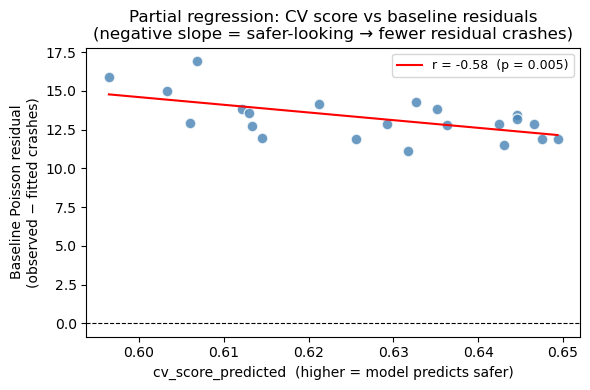

Partial correlation (cv_score ⊥ infrastructure): r = -0.581  (p = 0.005)


In [9]:
# ── Coefficient comparison table (Poisson, IRR scale) ─────────────────────────
def coef_table(result):
    coef = result.params
    ci   = result.conf_int()
    return pd.DataFrame({
        "IRR"    : np.exp(coef),
        "CI_low" : np.exp(ci.iloc[:, 0]),
        "CI_high": np.exp(ci.iloc[:, 1]),
        "p"      : result.pvalues,
    }).round(4)

tbl_base = coef_table(pois_base).add_suffix("_base")
tbl_enr  = coef_table(pois_enr).add_suffix("_enr")

# Outer join so cv_score row (absent from baseline) appears with NaN on the left
comparison = tbl_base.join(tbl_enr, how="outer")
comparison["sig"] = comparison["p_enr"].apply(
    lambda p: "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05
              else "." if p < 0.1 else "" if pd.notna(p) else ""
)

print("Coefficient table (Poisson, IRR scale) — baseline vs enriched:")
print(comparison.to_string())
print()

# Highlight the CV score row specifically
cv_irr = np.exp(pois_enr.params["cv_score_predicted"])
cv_ci  = np.exp(pois_enr.conf_int().loc["cv_score_predicted"])
cv_p   = pois_enr.pvalues["cv_score_predicted"]
print(f"cv_score IRR   : {cv_irr:.3f}")
print(f"95% CI         : [{cv_ci.iloc[0]:.3f}, {cv_ci.iloc[1]:.3f}]")
print(f"p-value        : {cv_p:.4f}")
print(f"Interpretation : a +0.1 change in cv_score multiplies expected crashes by "
      f"{np.exp(0.1 * pois_enr.params['cv_score_predicted']):.3f}")
print()
print("Note: CIs are very wide with n=22. Direction more informative than magnitude.")

# ── Partial regression plot ────────────────────────────────────────────────────
# Baseline residuals vs cv_score — shows cv_score's added value after controlling
# for the infrastructure variables already in the model
resid_base = df_p4["crash_count"].values - np.asarray(pois_base.fittedvalues)

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(df_p4["cv_score_predicted"], resid_base,
           color="steelblue", alpha=0.8, s=60, edgecolors="white")
ax.axhline(0, color="black", lw=0.8, ls="--")

# OLS trendline on the partial plot
m, b_int, r_part, p_part, _ = stats.linregress(
    df_p4["cv_score_predicted"], resid_base
)
x_line = np.linspace(df_p4["cv_score_predicted"].min(),
                     df_p4["cv_score_predicted"].max(), 100)
ax.plot(x_line, m * x_line + b_int, "r-", lw=1.5,
        label=f"r = {r_part:.2f}  (p = {p_part:.3f})")

ax.set_xlabel("cv_score_predicted  (higher = model predicts safer)")
ax.set_ylabel("Baseline Poisson residual\n(observed − fitted crashes)")
ax.set_title("Partial regression: CV score vs baseline residuals\n"
             "(negative slope = safer-looking → fewer residual crashes)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(PLOTS / "nb04_partial_regression.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Partial correlation (cv_score ⊥ infrastructure): r = {r_part:.3f}  (p = {p_part:.3f})")

## 4. Measurement Error Note

The CV score is a *predicted* score, not the true visual safety of the intersection.
It carries estimation error equal to the CV model's validation MAE (≈ 0.189 on the 0–1 scale).

Classical measurement error in a predictor causes **attenuation bias**: the estimated
β for `cv_score_predicted` is biased toward zero. The true effect of visual safety on
crash frequency is therefore likely *larger* in magnitude than what the model estimates.

The severity of attenuation depends on the signal-to-noise ratio:

> Attenuation factor ≈ σ²_true / (σ²_true + σ²_error)

In the pilot data, the score range is extremely narrow (σ ≈ 0.017) while the MAE is 0.189,
so virtually all variation in the score is noise. Once the full survey is collected and the
CV model is retrained, the score range will widen substantially and the attenuation will
decrease.

**Action (full data):** Run a simulation-based errors-in-variables sensitivity analysis
as specified in Proposal Section 4.4.4, varying the assumed measurement error between
0.5× and 1.5× the observed MAE.

## 5. Save Results

In [10]:
# Save the best converged enriched model for downstream use
best_enr = nb_enr if nb_enr.mle_retvals["converged"] else pois_enr
model_label = "NB2" if nb_enr.mle_retvals["converged"] else "Poisson"

with open(OUTPUTS / "model_enriched.pkl", "wb") as f:
    pickle.dump(best_enr, f)
print(f"Saved model_enriched.pkl  ({model_label})")

# Alpha from NB enriched (if it converged)
if nb_enr.mle_retvals["converged"]:
    alpha_enr = float(np.exp(nb_enr.params["alpha"])) if "alpha" in nb_enr.params.index else None
else:
    alpha_enr = None

# Helper: build a serialisable coefficient dict from a fitted result
def coef_dict(result):
    coef = result.params
    ci   = result.conf_int()
    return {
        var: {
            "coef"   : float(coef[var]),
            "irr"    : float(np.exp(coef[var])),
            "ci_low" : float(np.exp(ci.loc[var].iloc[0])),
            "ci_high": float(np.exp(ci.loc[var].iloc[1])),
            "p"      : float(result.pvalues[var]),
        }
        for var in coef.index
    }

full_results = {
    "n_obs_phase4"         : int(len(df_p4)),
    "n_dropped_missing_cv" : int(n_dropped_cv),
    "baseline_vars"        : selected_vars,
    "enriched_vars"        : ENRICHED_VARS,
    "poisson": {
        "baseline" : {"aic": float(pois_base.aic), "ll": float(pois_base.llf),
                      "converged": bool(pois_base.mle_retvals["converged"]),
                      "coefficients": coef_dict(pois_base)},
        "enriched" : {"aic": float(pois_enr.aic),  "ll": float(pois_enr.llf),
                      "converged": bool(pois_enr.mle_retvals["converged"]),
                      "coefficients": coef_dict(pois_enr)},
        "lr_stat"  : float(lr_stat_pois),
        "lr_p"     : float(p_pois),
        "delta_aic": float(pois_base.aic - pois_enr.aic),
    },
    "nb2": {
        "baseline_converged": bool(nb_base.mle_retvals["converged"]),
        "enriched_converged": bool(nb_enr.mle_retvals["converged"]),
        "lr_stat"           : float(lr_stat_nb),
        "lr_p"              : float(p_nb),
        "delta_aic"         : float(nb_base.aic - nb_enr.aic),
        "alpha_enriched"    : alpha_enr,
    },
    "note": (
        "Pilot data (n=22). Poisson primary (NB2 may not converge with small n). "
        "Re-run with full survey data for definitive results."
    ),
}

results_path = OUTPUTS / "nb_model_results.json"
with open(results_path, "w") as f:
    json.dump(full_results, f, indent=2)
print(f"Saved nb_model_results.json")

# Thesis-ready side-by-side CSV — drop the significance column (thesis table uses raw p-values)
comparison_export = comparison.drop(columns=["sig"])
comparison_export.to_csv(OUTPUTS / "nb_comparison_table.csv")
print(f"Saved nb_comparison_table.csv")

Saved model_enriched.pkl  (Poisson)
Saved nb_model_results.json
Saved nb_comparison_table.csv


## Handover

**Produced:**
- `outputs/model_enriched.pkl` — best converged enriched model (NB2 if converged, else Poisson)
- `outputs/nb_model_results.json` — full results for both models + LR test
- `outputs/nb_comparison_table.csv` — side-by-side coefficient table (thesis-ready)
- `outputs/diagnostic_plots/nb04_partial_regression.png` — CV score vs baseline residuals

**Measurement error caveat:**
The CV score has prediction error ≈ MAE = 0.189 (0–1 scale). Classical errors-in-variables
attenuates β toward zero — the true visual-safety effect is likely larger than estimated.
With the narrow pilot score range (σ ≈ 0.017) the attenuation is severe; this will improve
with the full survey data and a retrained CV model.

**Written conclusion answering RQ4 (fill in after running):**
- LR test p-value (Poisson) → *[see Section 2]*
- ΔAIC (baseline − enriched) → *[see Section 2]*
- CV score IRR and direction → *[see Section 3]*
- Partial correlation after controlling for infrastructure → *[see Section 3 plot]*
- **Caution:** n=22 pilot data. All results illustrative only.